# Let's get the attention maps of the real car

In [68]:
# Start by loading the model

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from network.models.architectures.CIL_multiview.CIL_multiview import CIL_multiview
import os
import json
import torch
import torchvision.transforms.functional as TF

from configs import g_conf, set_type_of_process, merge_with_yaml
from _utils.training_utils import check_saved_checkpoints
from _utils import eval_utils
from einops import rearrange

import numpy as np
import matplotlib.pyplot as plt


os.environ["CUDA_VISIBLE_DEVICES"] = "2"

# Load the configuration for the model (folder and experiment name)
exp_batch = 'CILv2'  # Folder
exp_name = 'CILv2_old_arch_11h_c1h_shift200ms_parking_cerdanyola_filtered'  # Configuration/experiment name

merge_with_yaml(os.path.join('configs', exp_batch, f'{exp_name}.yaml'))
g_conf.PROCESS_NAME = 'train_val'
g_conf.DATASET_PATH = '/data/122-2/Datasets/IL_multiview/60_120_180'

os.environ['DATASET_PATH'] = g_conf.DATASET_PATH

model = CIL_multiview(g_conf.MODEL_CONFIGURATION)

# Get the path to the latest checkpoint (if no ckpt_number is defined)
checkpoint_path = os.path.join('/data-net/tda-2/Experiments/gvillalonga/cil_multiview_uab_dpp_slow_corrections_jun/', 
                               '_results', g_conf.EXPERIMENT_BATCH_NAME, g_conf.EXPERIMENT_NAME, 'checkpoints')

eval_utils.load_model_from_checkpoint(model=model, checkpoint_path=checkpoint_path, checkpoint_number=45, remove_pos_enc=False)

CIL_multiview(
  (encoder_embedding_perception): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=

In [2]:
!ls /data/122-2/Datasets/IL_multiview/60_120_180/03-feb-23/ruben_sunny

RouteScenario_0000


In [ ]:
!ls /data/122-2/Datasets/IL_multiview/60_120_180/03-feb-23/ruben_sunny/RouteScenario_0000

# conti_front_rosbag2_2023_02_03-12_19_32_1675423173_093454000.png
# conti_front_rosbag2_2023_02_03-12_19_32_1675423173_143446000.png
# conti_front_rosbag2_2023_02_03-12_19_32_1675423173_193468000.png
# conti_front_rosbag2_2023_02_03-12_19_32_1675423173_243463000.png
# conti_front_rosbag2_2023_02_03-12_19_32_1675423173_293438000.png
# etc.

We must load a single datapoint and do a forward pass.

In [5]:
# load the data 
from dataloaders.transforms import canbus_normalization, train_transform

test_data_root_dir = '/data/122-2/Datasets/IL_multiview/60_120_180/03-feb-23/ruben_sunny/RouteScenario_0000'

First the RGB data

In [6]:
from PIL import Image

def open_image(img_name: str) -> Image.Image:
    img = Image.open(os.path.join(os.getcwd(), test_data_root_dir, img_name))
    if 'virtual_attention' in img_name:
        return img.convert('L')
    return img.convert('RGB')

img_paths_dict = {
    'sekonix_60': [open_image('sekonix_60_rosbag2_2023_02_03-12_19_32_1675423174_293398000.png')],
    'sekonix_120': [open_image('sekonix_120_rosbag2_2023_02_03-12_19_32_1675423174_293398000.png')],
    'conti_front': [open_image('conti_front_rosbag2_2023_02_03-12_19_32_1675423174_293398000.png')],
}


In [7]:
img_paths_dict['sekonix_60'][0].size

(576, 362)

In [61]:
for key, v in img_paths_dict.items():
    print(v[0].size)

(576, 362)
(576, 362)
(1280, 800)


Now the CAN bus data

In [9]:
canbus_paths = [os.path.join(os.getcwd(), test_data_root_dir, 'il_data_rosbag2_2023_02_03-12_19_32_1675423174_293398000.json')]

full_dataset = []

for camera_type, img_paths in img_paths_dict.items():
    if len(img_paths) != len(canbus_paths):
        print(camera_type, len(img_paths), len(canbus_paths))
        raise RuntimeError('The numbers of images and canbus data are not mathced!!')

for i in range(len(canbus_paths)):
    datapoint = {}
    datapoint['can_bus'] = dict()
    f = open(canbus_paths[i], 'r')
    canbus_data = json.loads(f.read())
    for value in g_conf.TARGETS + g_conf.OTHER_INPUTS:
        datapoint['can_bus'][value] = canbus_data[value]
    datapoint['can_bus'] = canbus_normalization(datapoint['can_bus'], g_conf.DATA_NORMALIZATION)
    for camera_type, img_paths in img_paths_dict.items():
        datapoint[camera_type] = img_paths[i]
    full_dataset.append(datapoint)

In [10]:
full_dataset

[{'can_bus': {'steer': 0.001322090562967789,
   'acceleration': 0.040716666666666665,
   'speed': 0.6235583333333333,
   'direction': [1, 0, 0, 0, 0, 0]},
  'sekonix_60': <PIL.Image.Image image mode=RGB size=576x362 at 0x7FAFFF9E4D10>,
  'sekonix_120': <PIL.Image.Image image mode=RGB size=576x362 at 0x7FAFFF1EA990>,
  'conti_front': <PIL.Image.Image image mode=RGB size=1280x800 at 0x7FAFF9931D50>}]

In [67]:
g_conf

{'__immutable__': False}

In [11]:
data = train_transform(full_dataset[0], (3, 300, 300))

src_images = [data[camera_type] for camera_type in g_conf.DATA_USED]
src_directions = [torch.tensor([data['can_bus']['direction']]).float()]
src_s = [torch.tensor([data['can_bus']['speed']]).float()]

x = torch.stack(src_images)
d = src_directions[-1]
s = src_s[-1]

e_p, resnet_inter = model.encoder_embedding_perception(x)

e_p = rearrange(e_p, 'b dim h w -> 1 (b h w) dim')

e_d = model.command(d).unsqueeze(1)
e_s = model.speed(s).unsqueeze(0).unsqueeze(0)

In [12]:
e_p = e_p + e_d + e_s
e_p = model.positional_encoding(e_p)

in_memory, attn_weights = model.tx_encoder(e_p)

print(model.action_prediction(in_memory, 3))

(tensor([[[0.0013, 0.0138]]], grad_fn=<UnsqueezeBackward0>), None, None)


## Now the attention weights

In [13]:
resnet_inter[0].shape

torch.Size([3, 64, 150, 150])

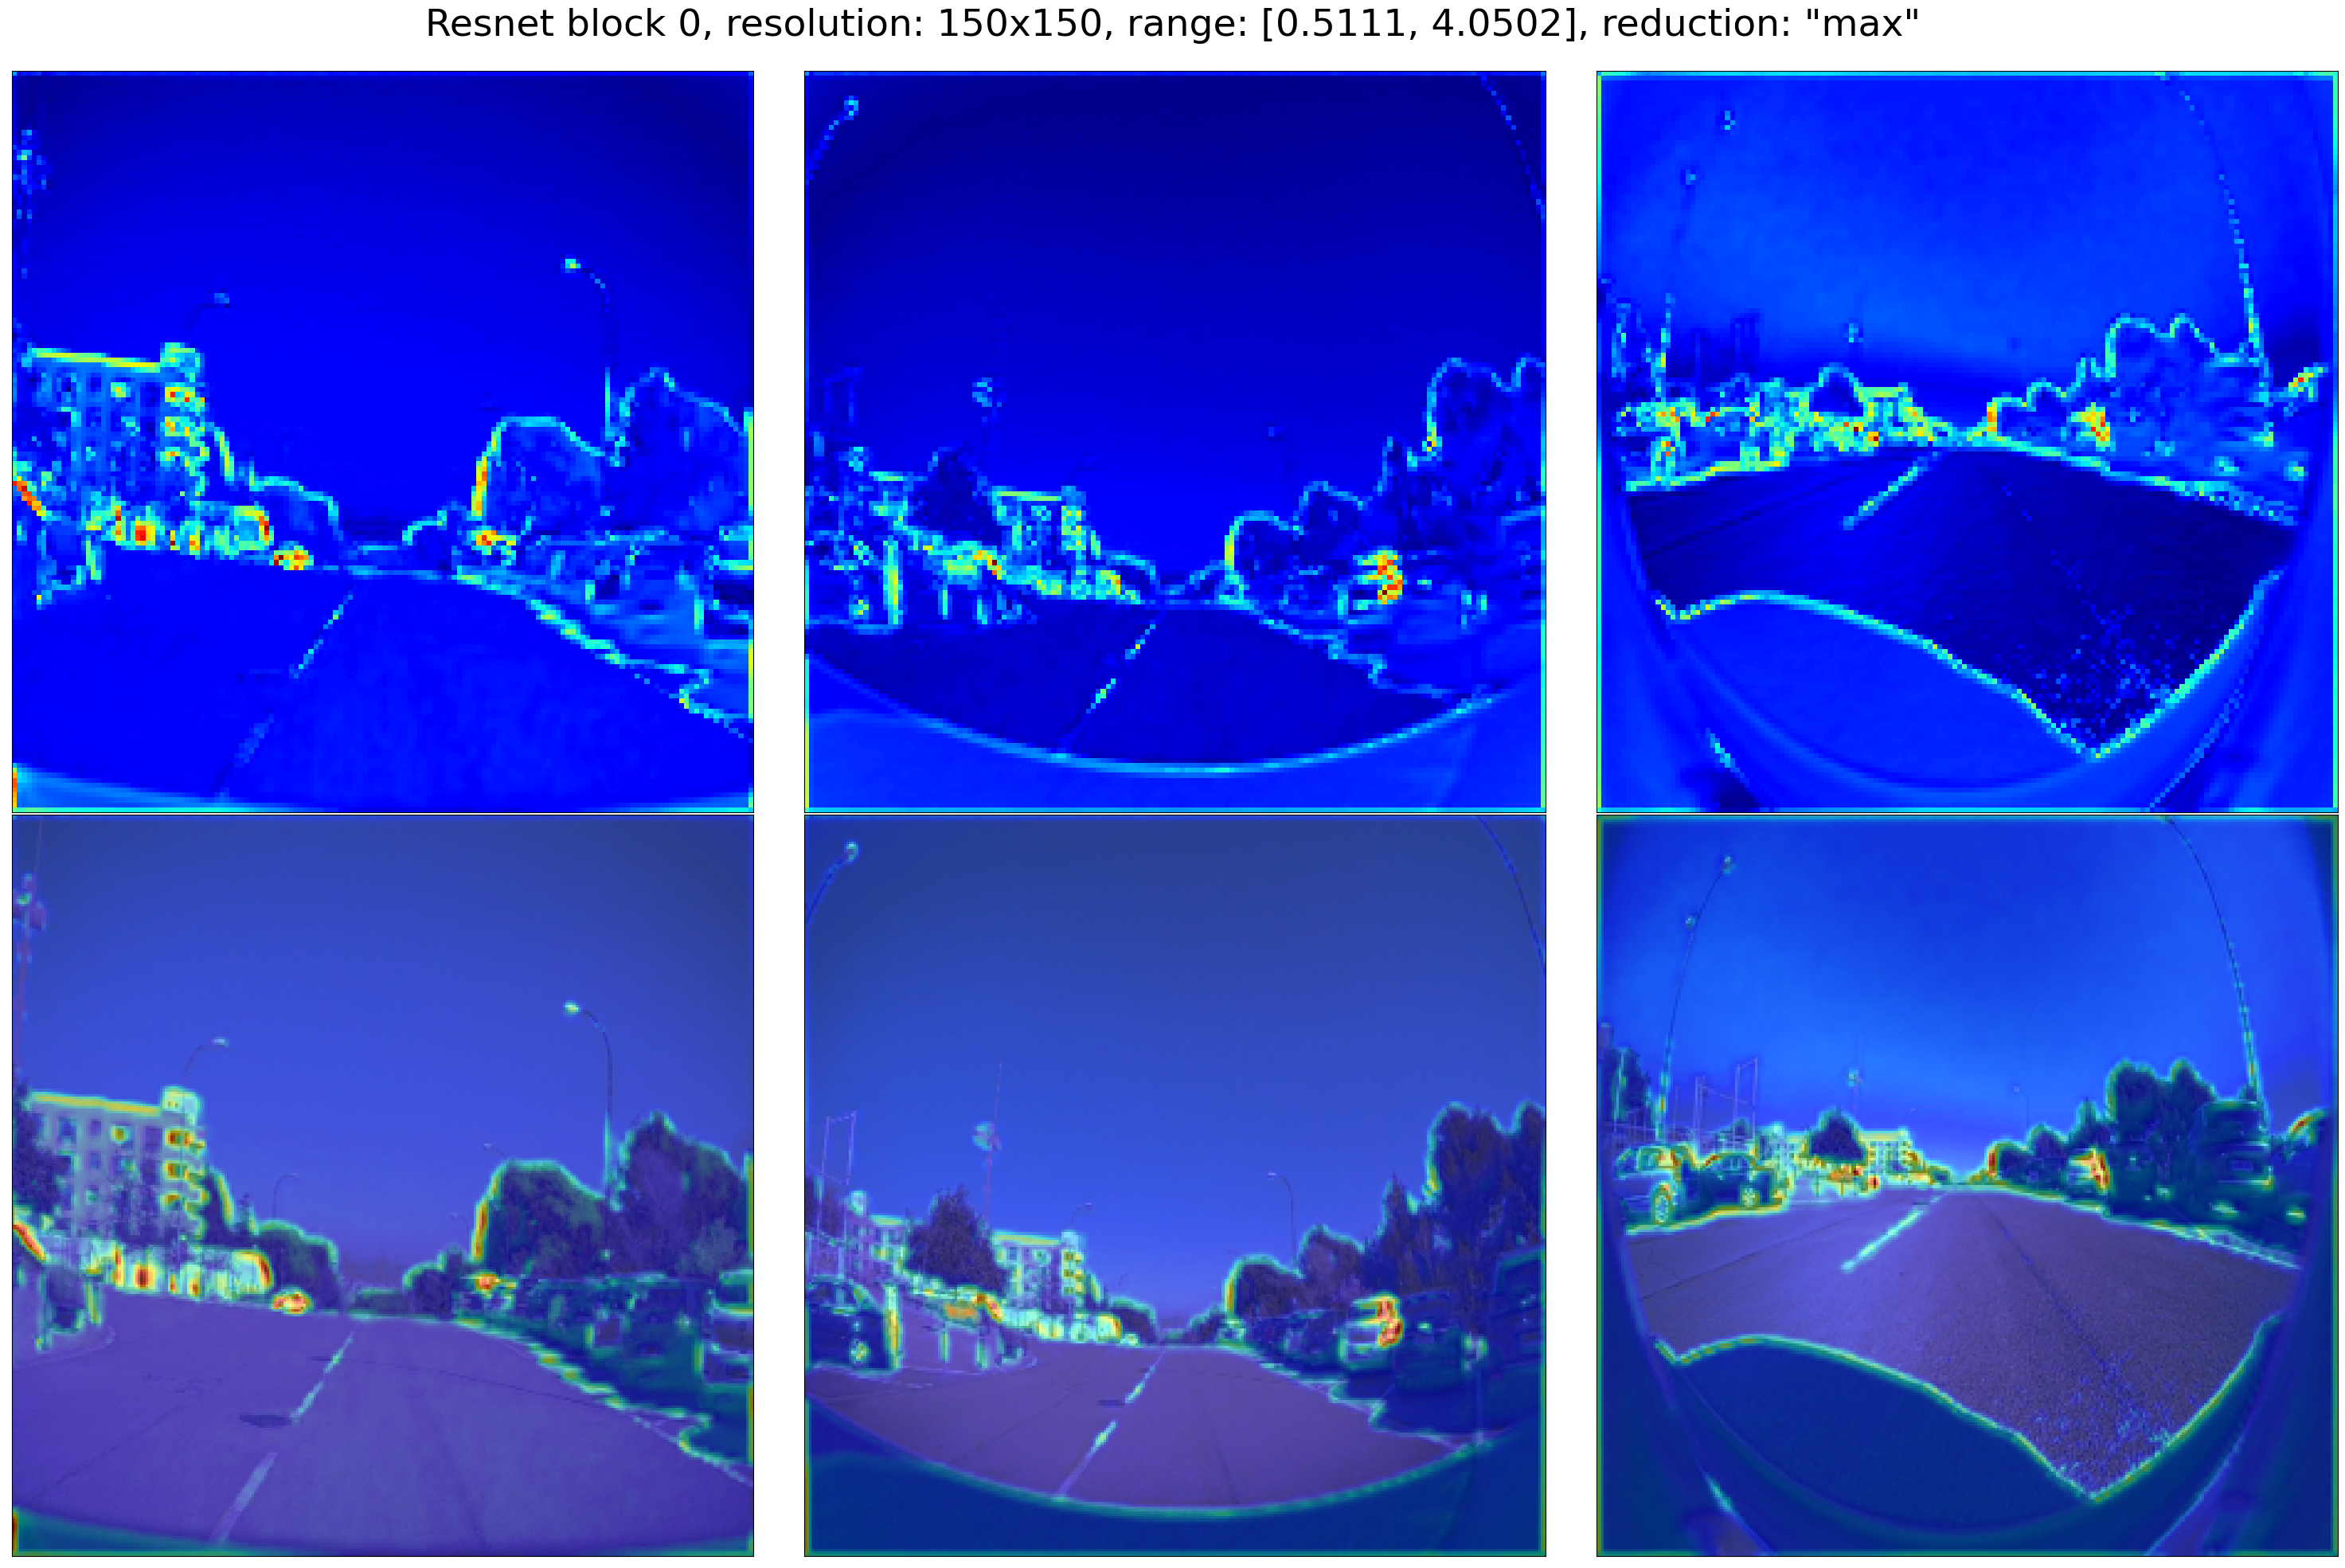

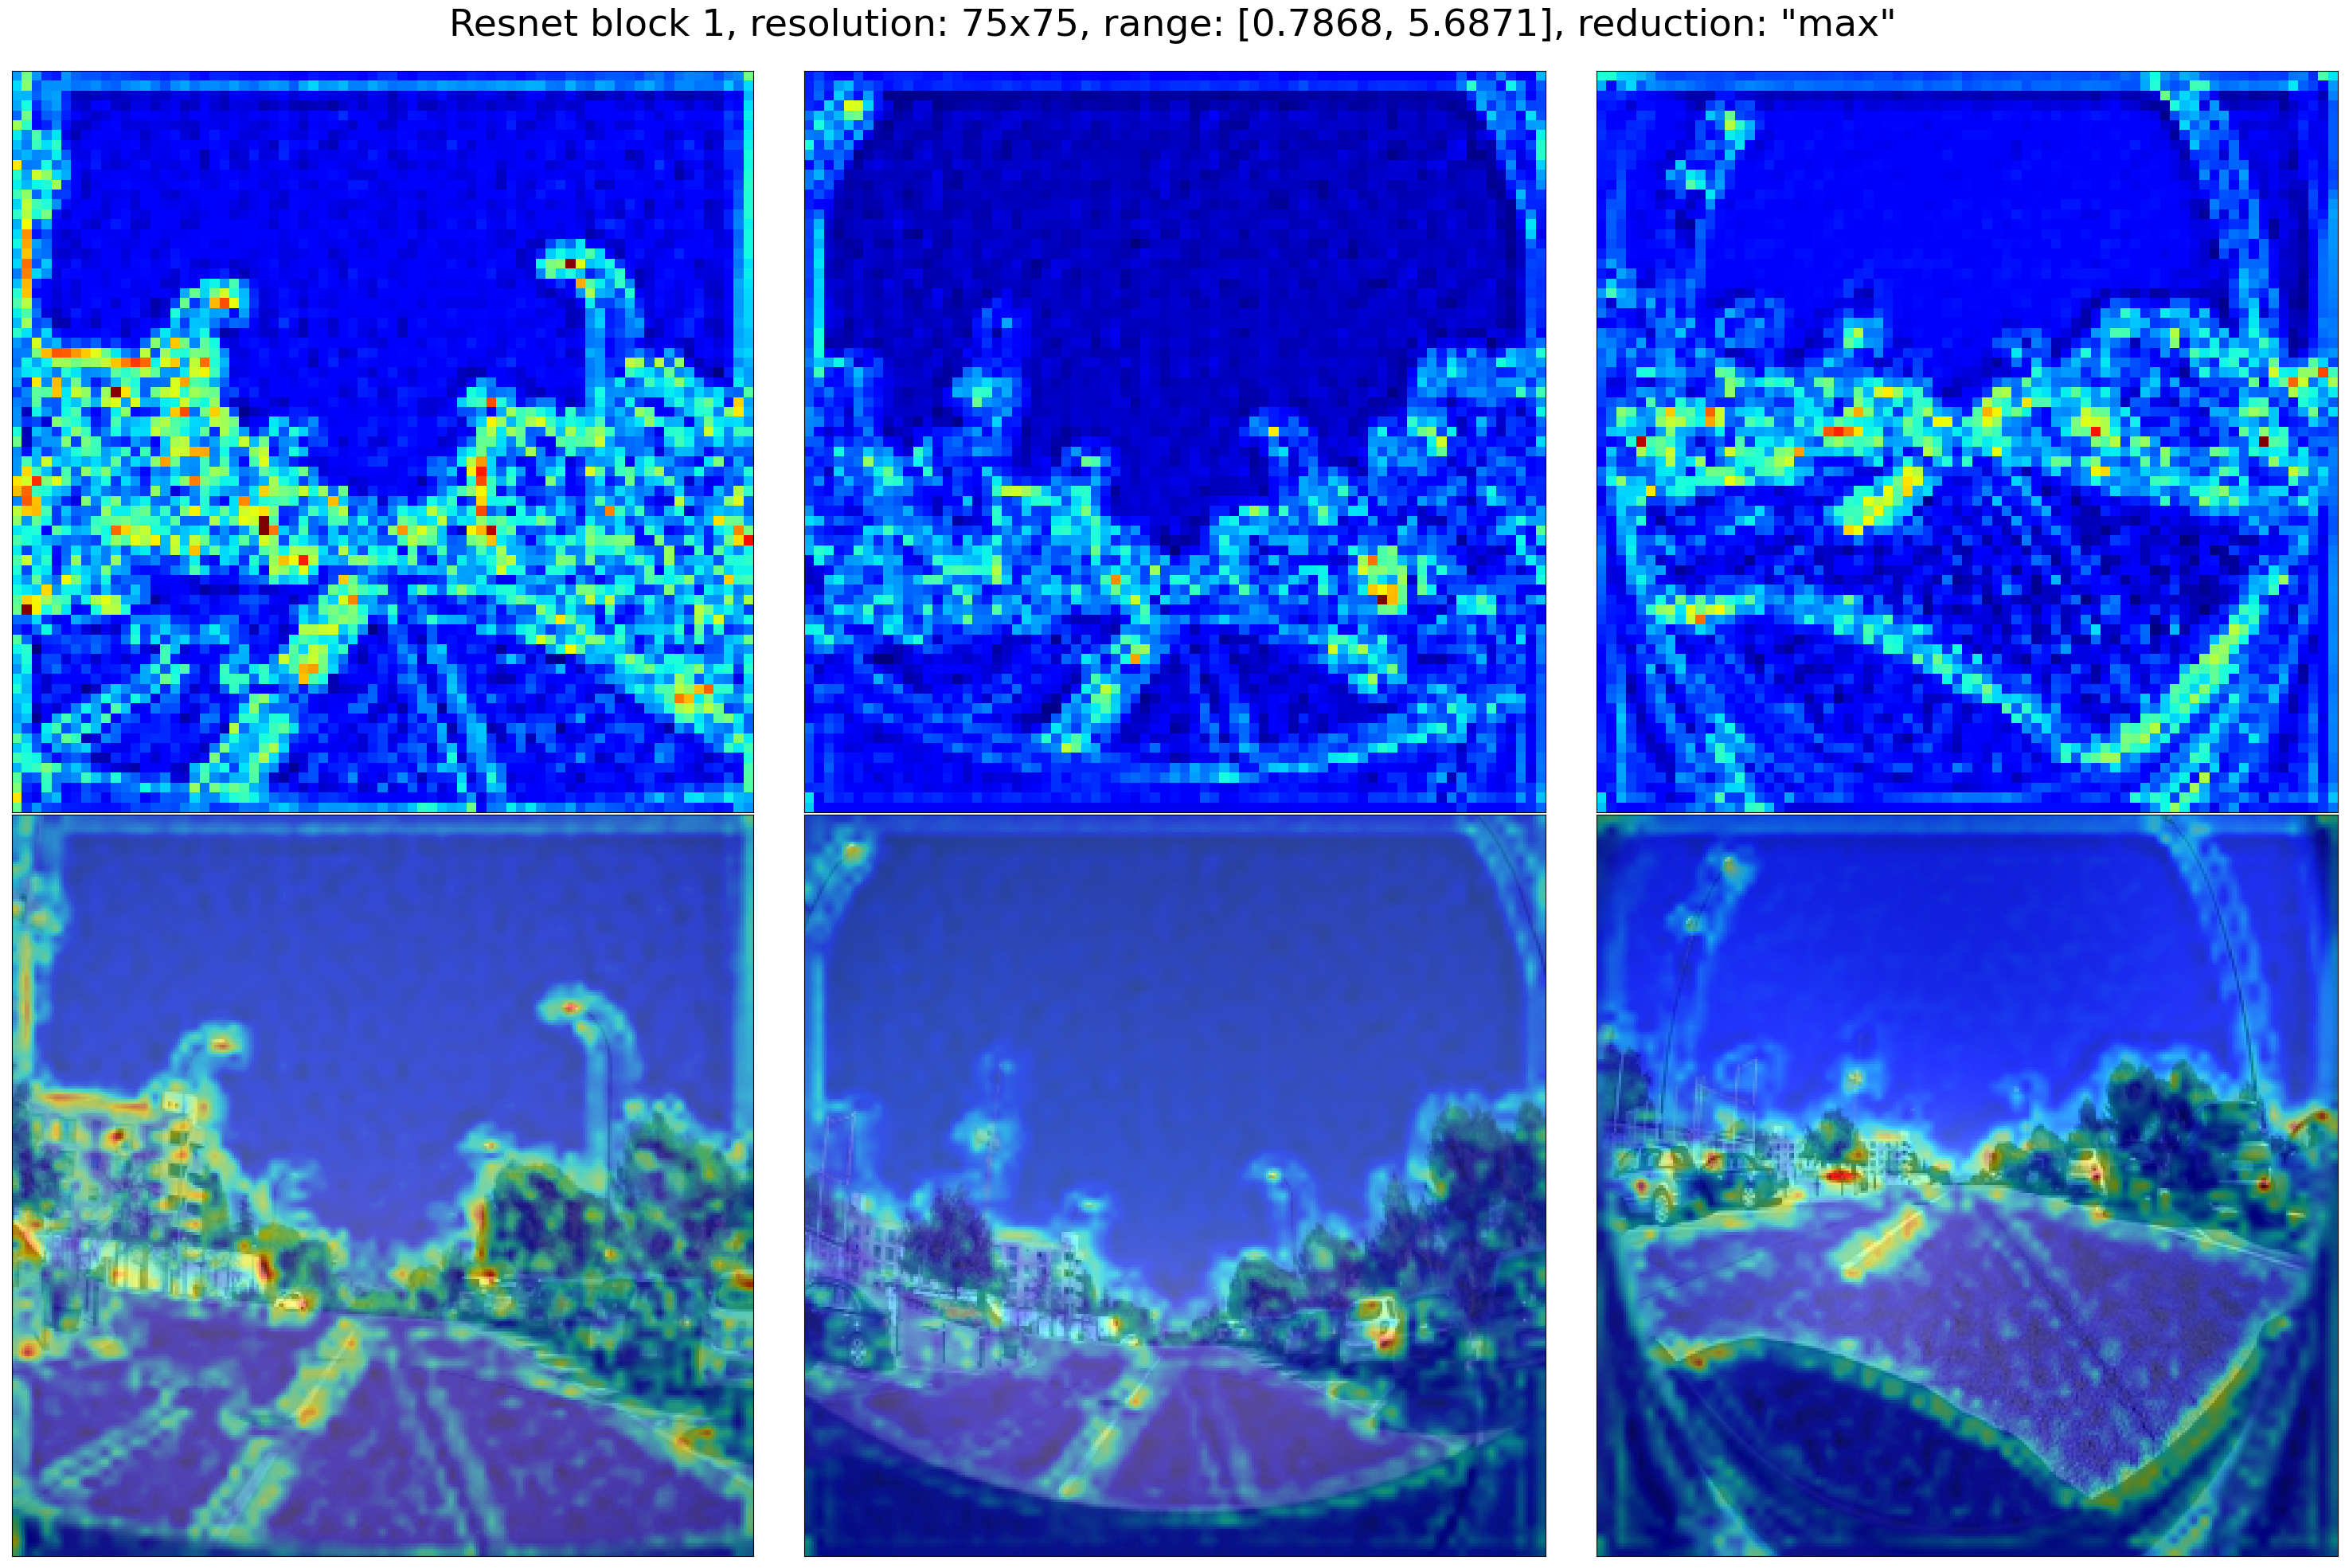

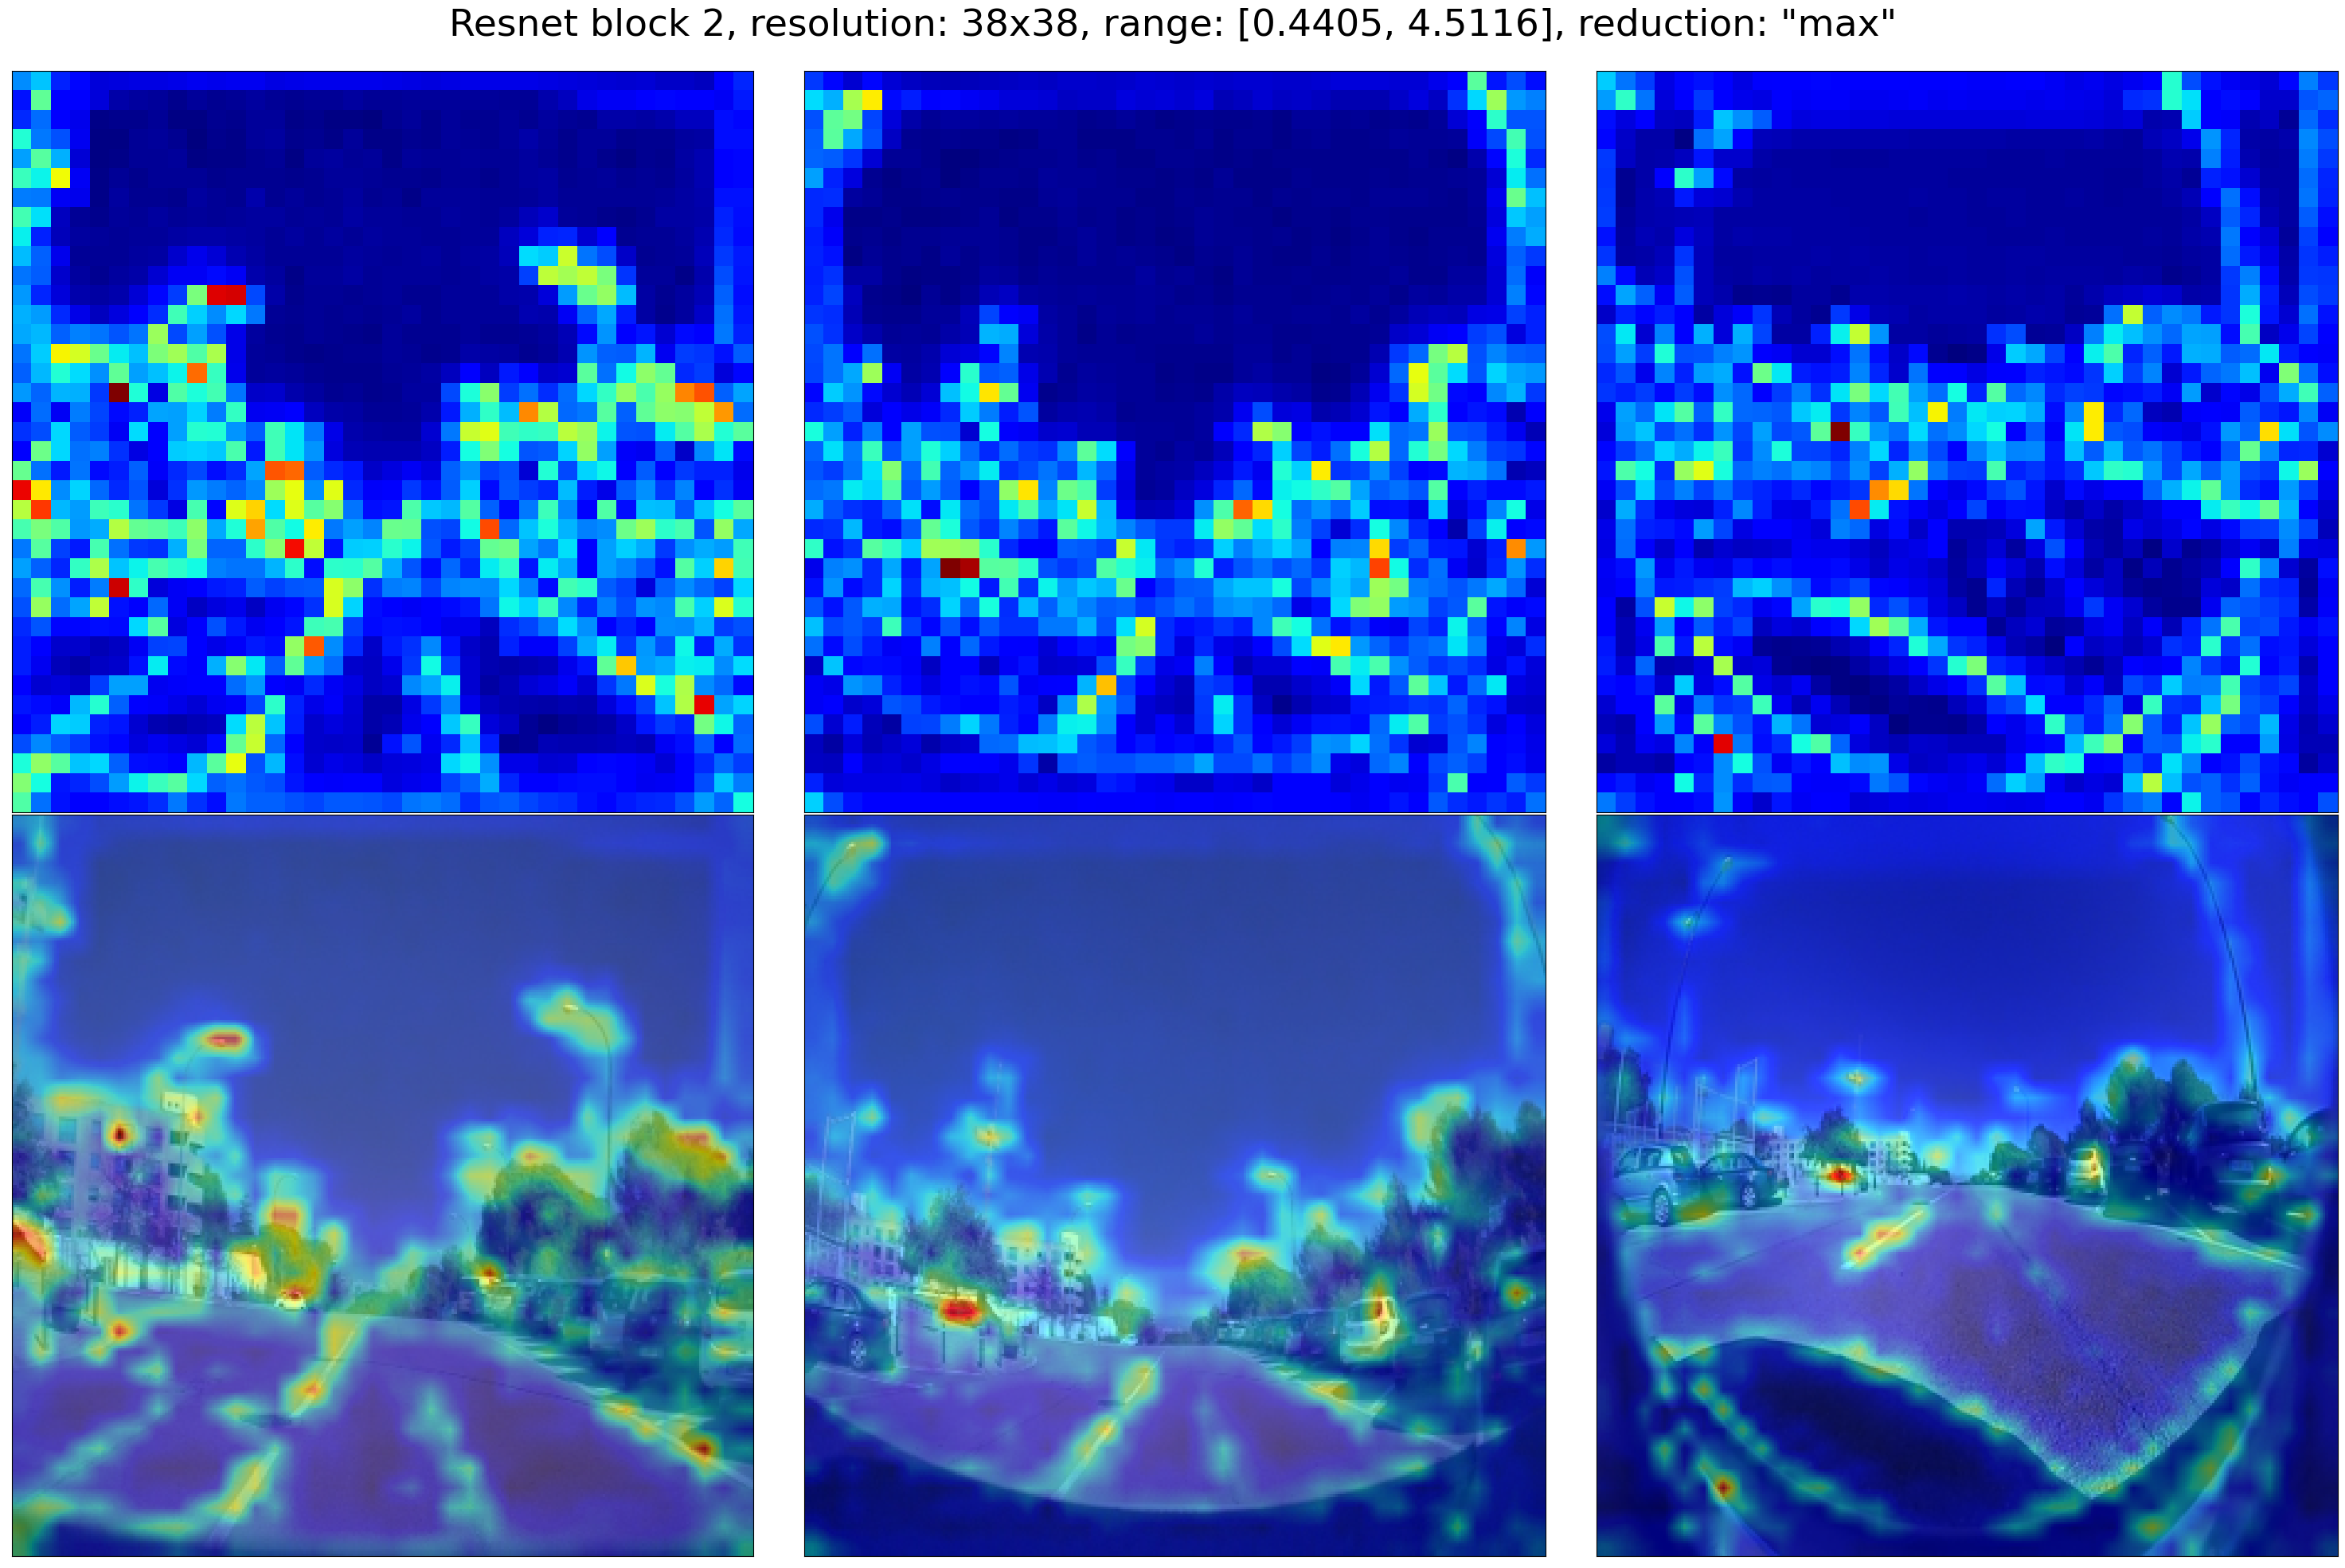

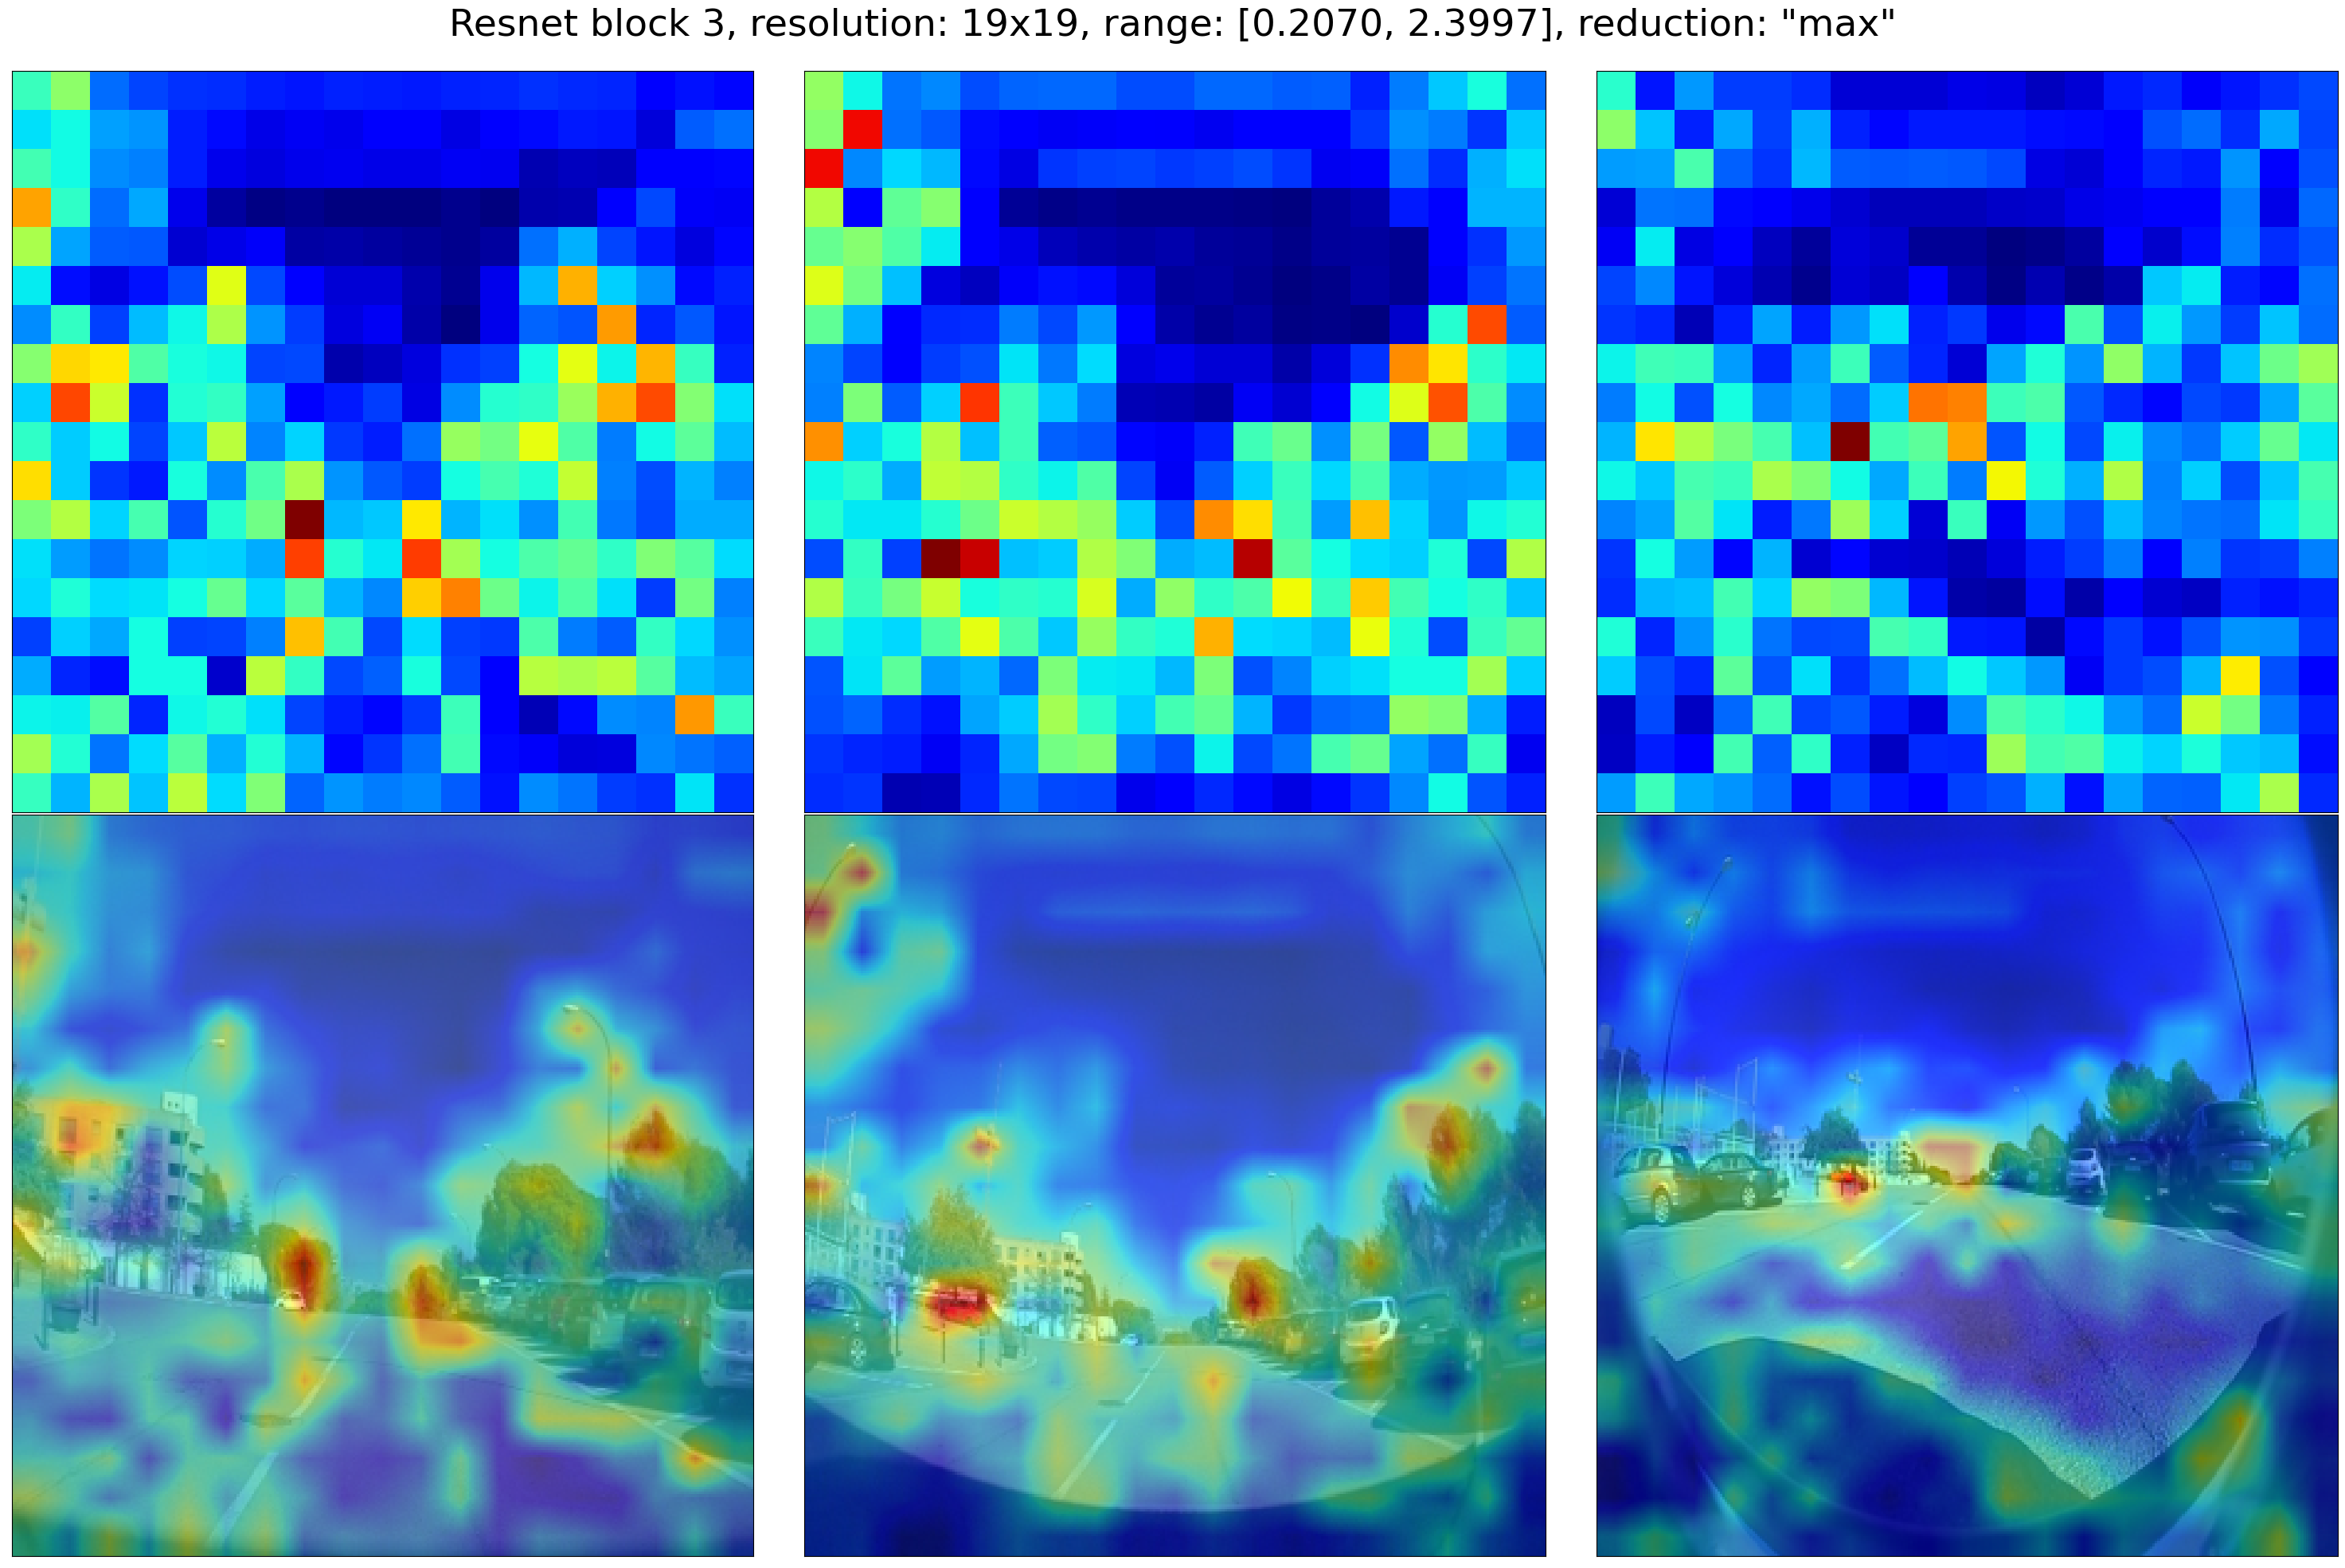

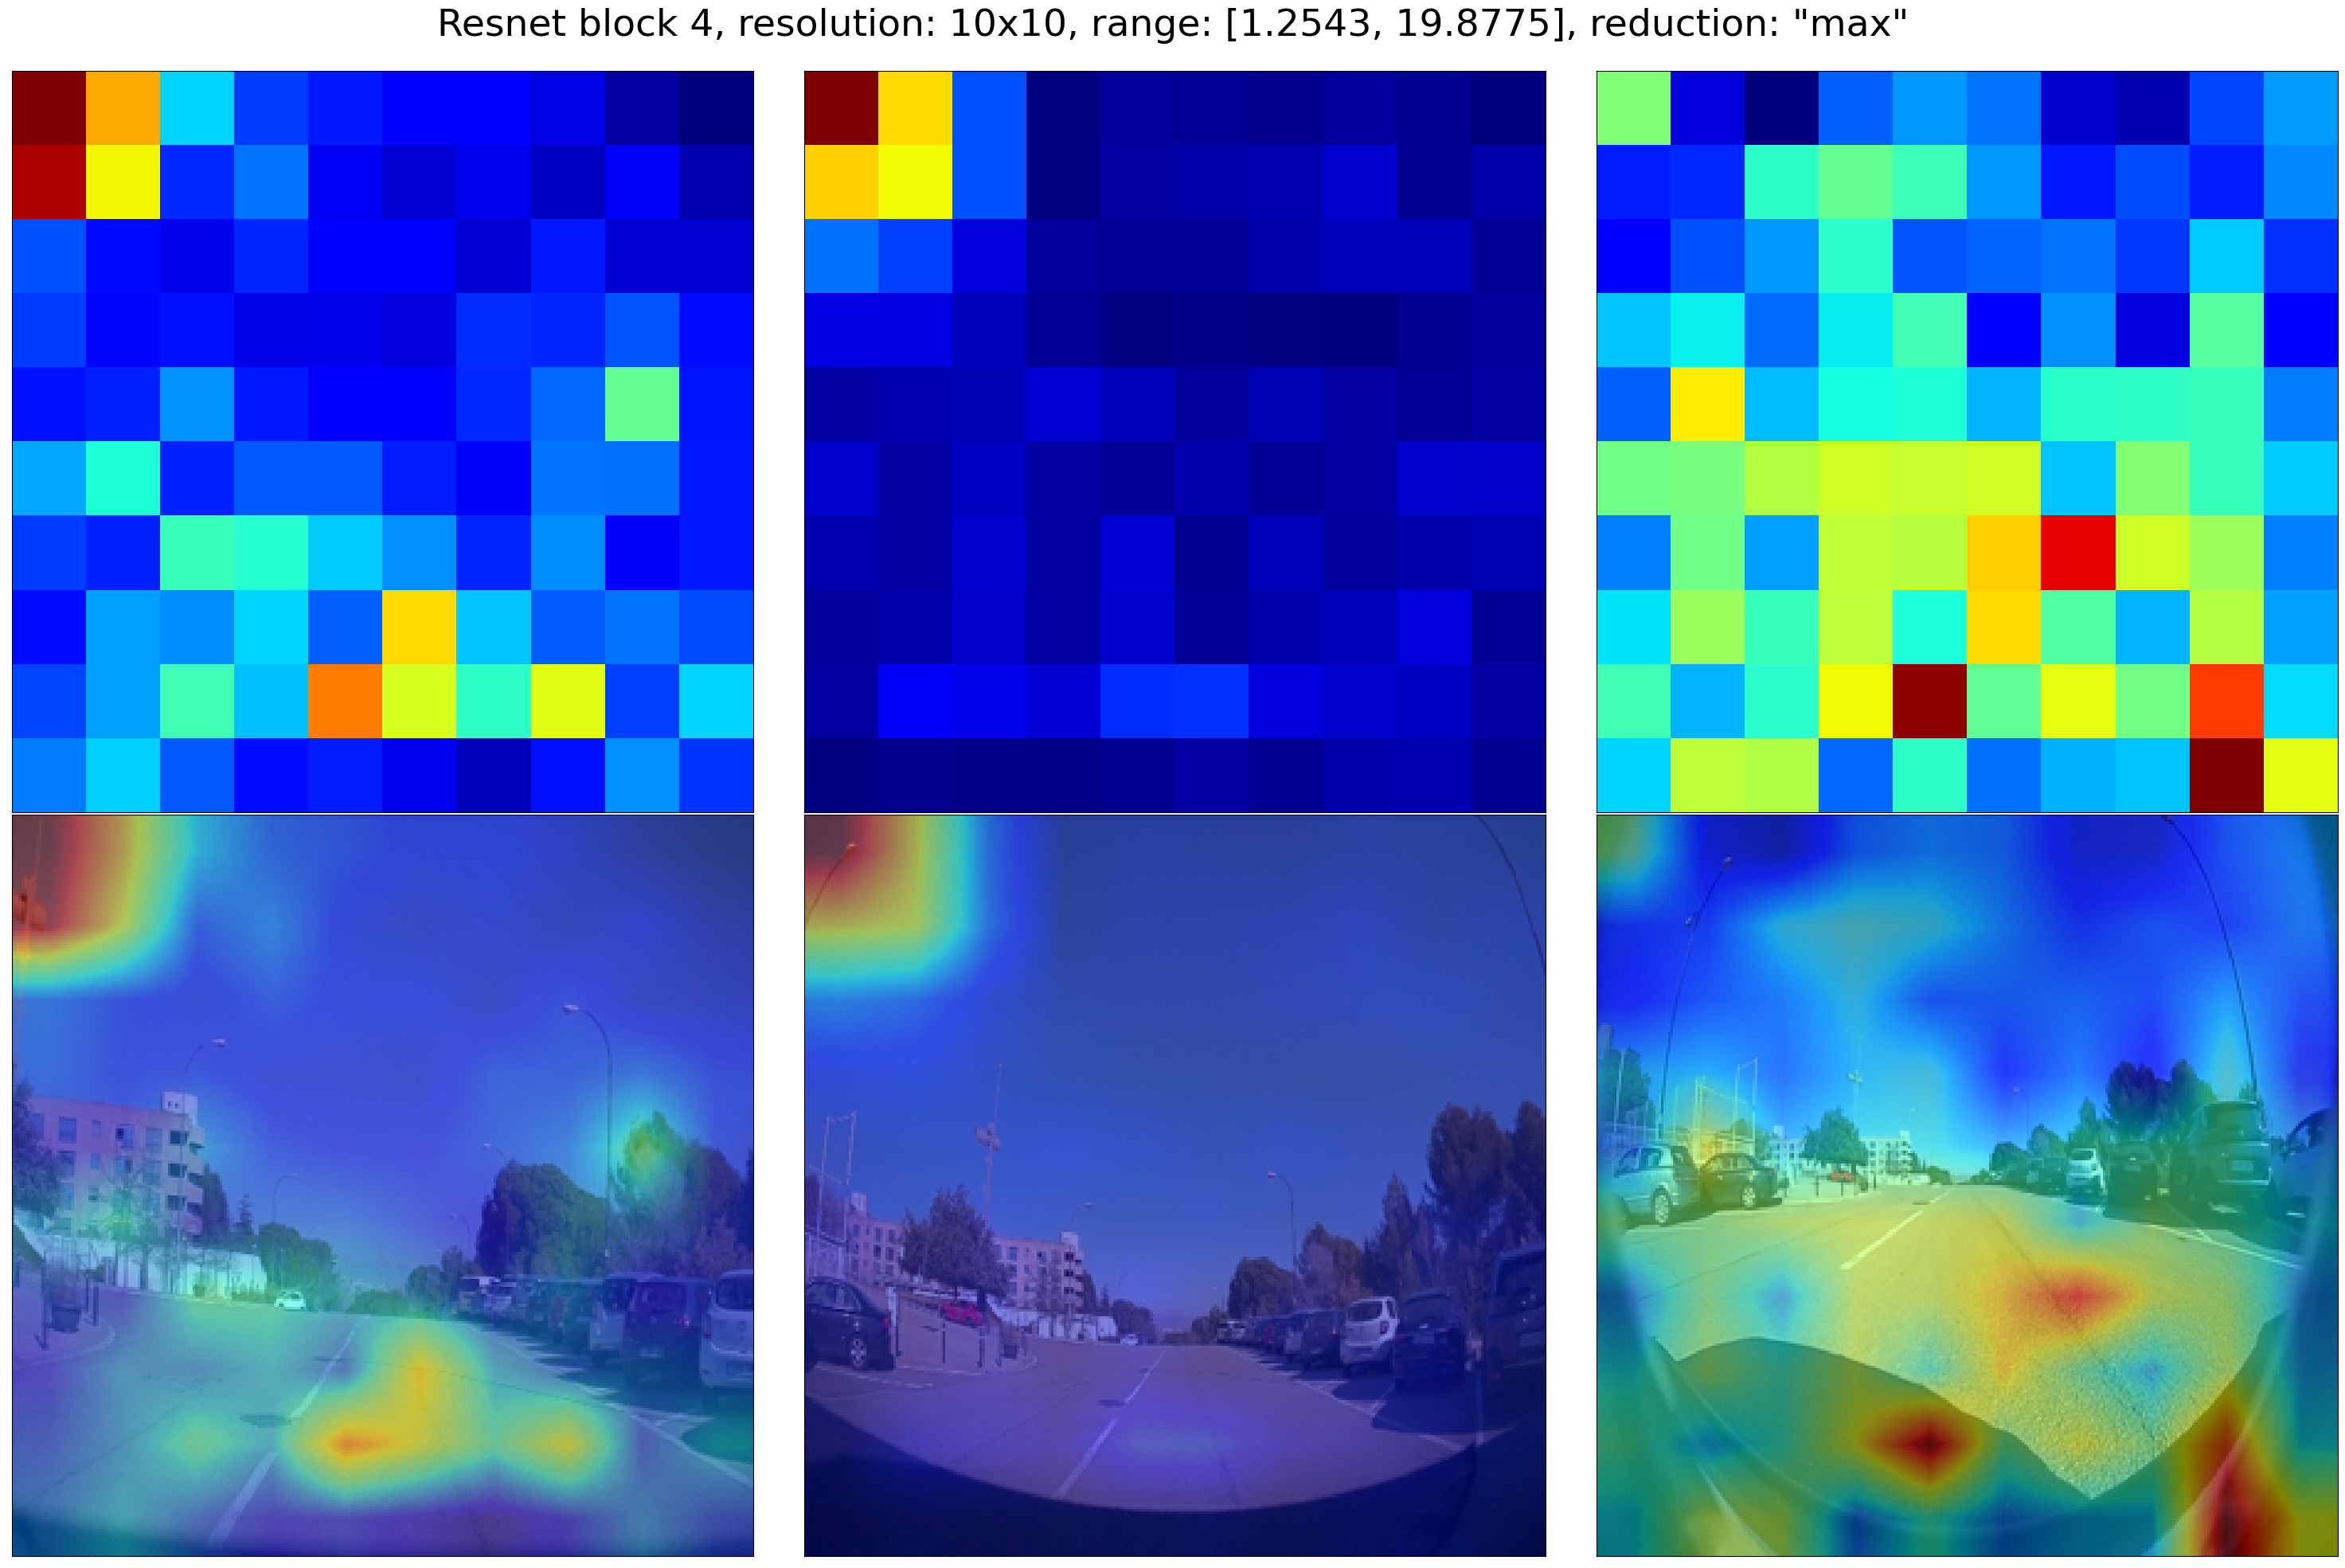

In [15]:
import torchvision.transforms.functional as TF
from einops import reduce
import cv2
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

reduction = 'max'

for idx, res in enumerate(resnet_inter):
    num_cameras = res.shape[0]
    # Average over the channels (dim=1)
    res = reduce(res, 'cam dim h w -> cam h w', reduction)
    
    # Plot the three cameras side by side
    fig, ax = plt.subplots(2, num_cameras, figsize=(10 * num_cameras, 20))
    fig.suptitle(f'Resnet block {idx}, resolution: {res.shape[-1]}x{res.shape[-1]}, range: [{res.min().item():.4f}, {res.max().item():.4f}], reduction: "{reduction}"', fontsize=34)

    for cam in range(num_cameras):
        ax[0, cam].imshow(res.detach().numpy()[cam], cmap='jet')
        ax[0, cam].set_xticks([])
        ax[0, cam].set_yticks([])

        img = src_images[cam]
        img = TF.normalize(img, [-0.485/0.229, -0.456/0.224, -0.406/0.255], [1/0.229, 1/0.224, 1/0.255])
        img = torch.clamp(img, 0, 1)

        res_up = cv2.resize(res.detach().numpy()[cam], (img.size(1), img.size(2)), interpolation=cv2.INTER_LINEAR)
        # res_up = TF.resize(res[cam], img.size(-1), antialias=True)
        ax[1, cam].imshow(img.detach().numpy().transpose(1, 2, 0))
        ax[1, cam].imshow(res_up, cmap='jet', alpha=0.5)
        ax[1, cam].set_xticks([])
        ax[1, cam].set_yticks([])


    fig.tight_layout()
    fig.subplots_adjust(top=0.94)
    plt.show()

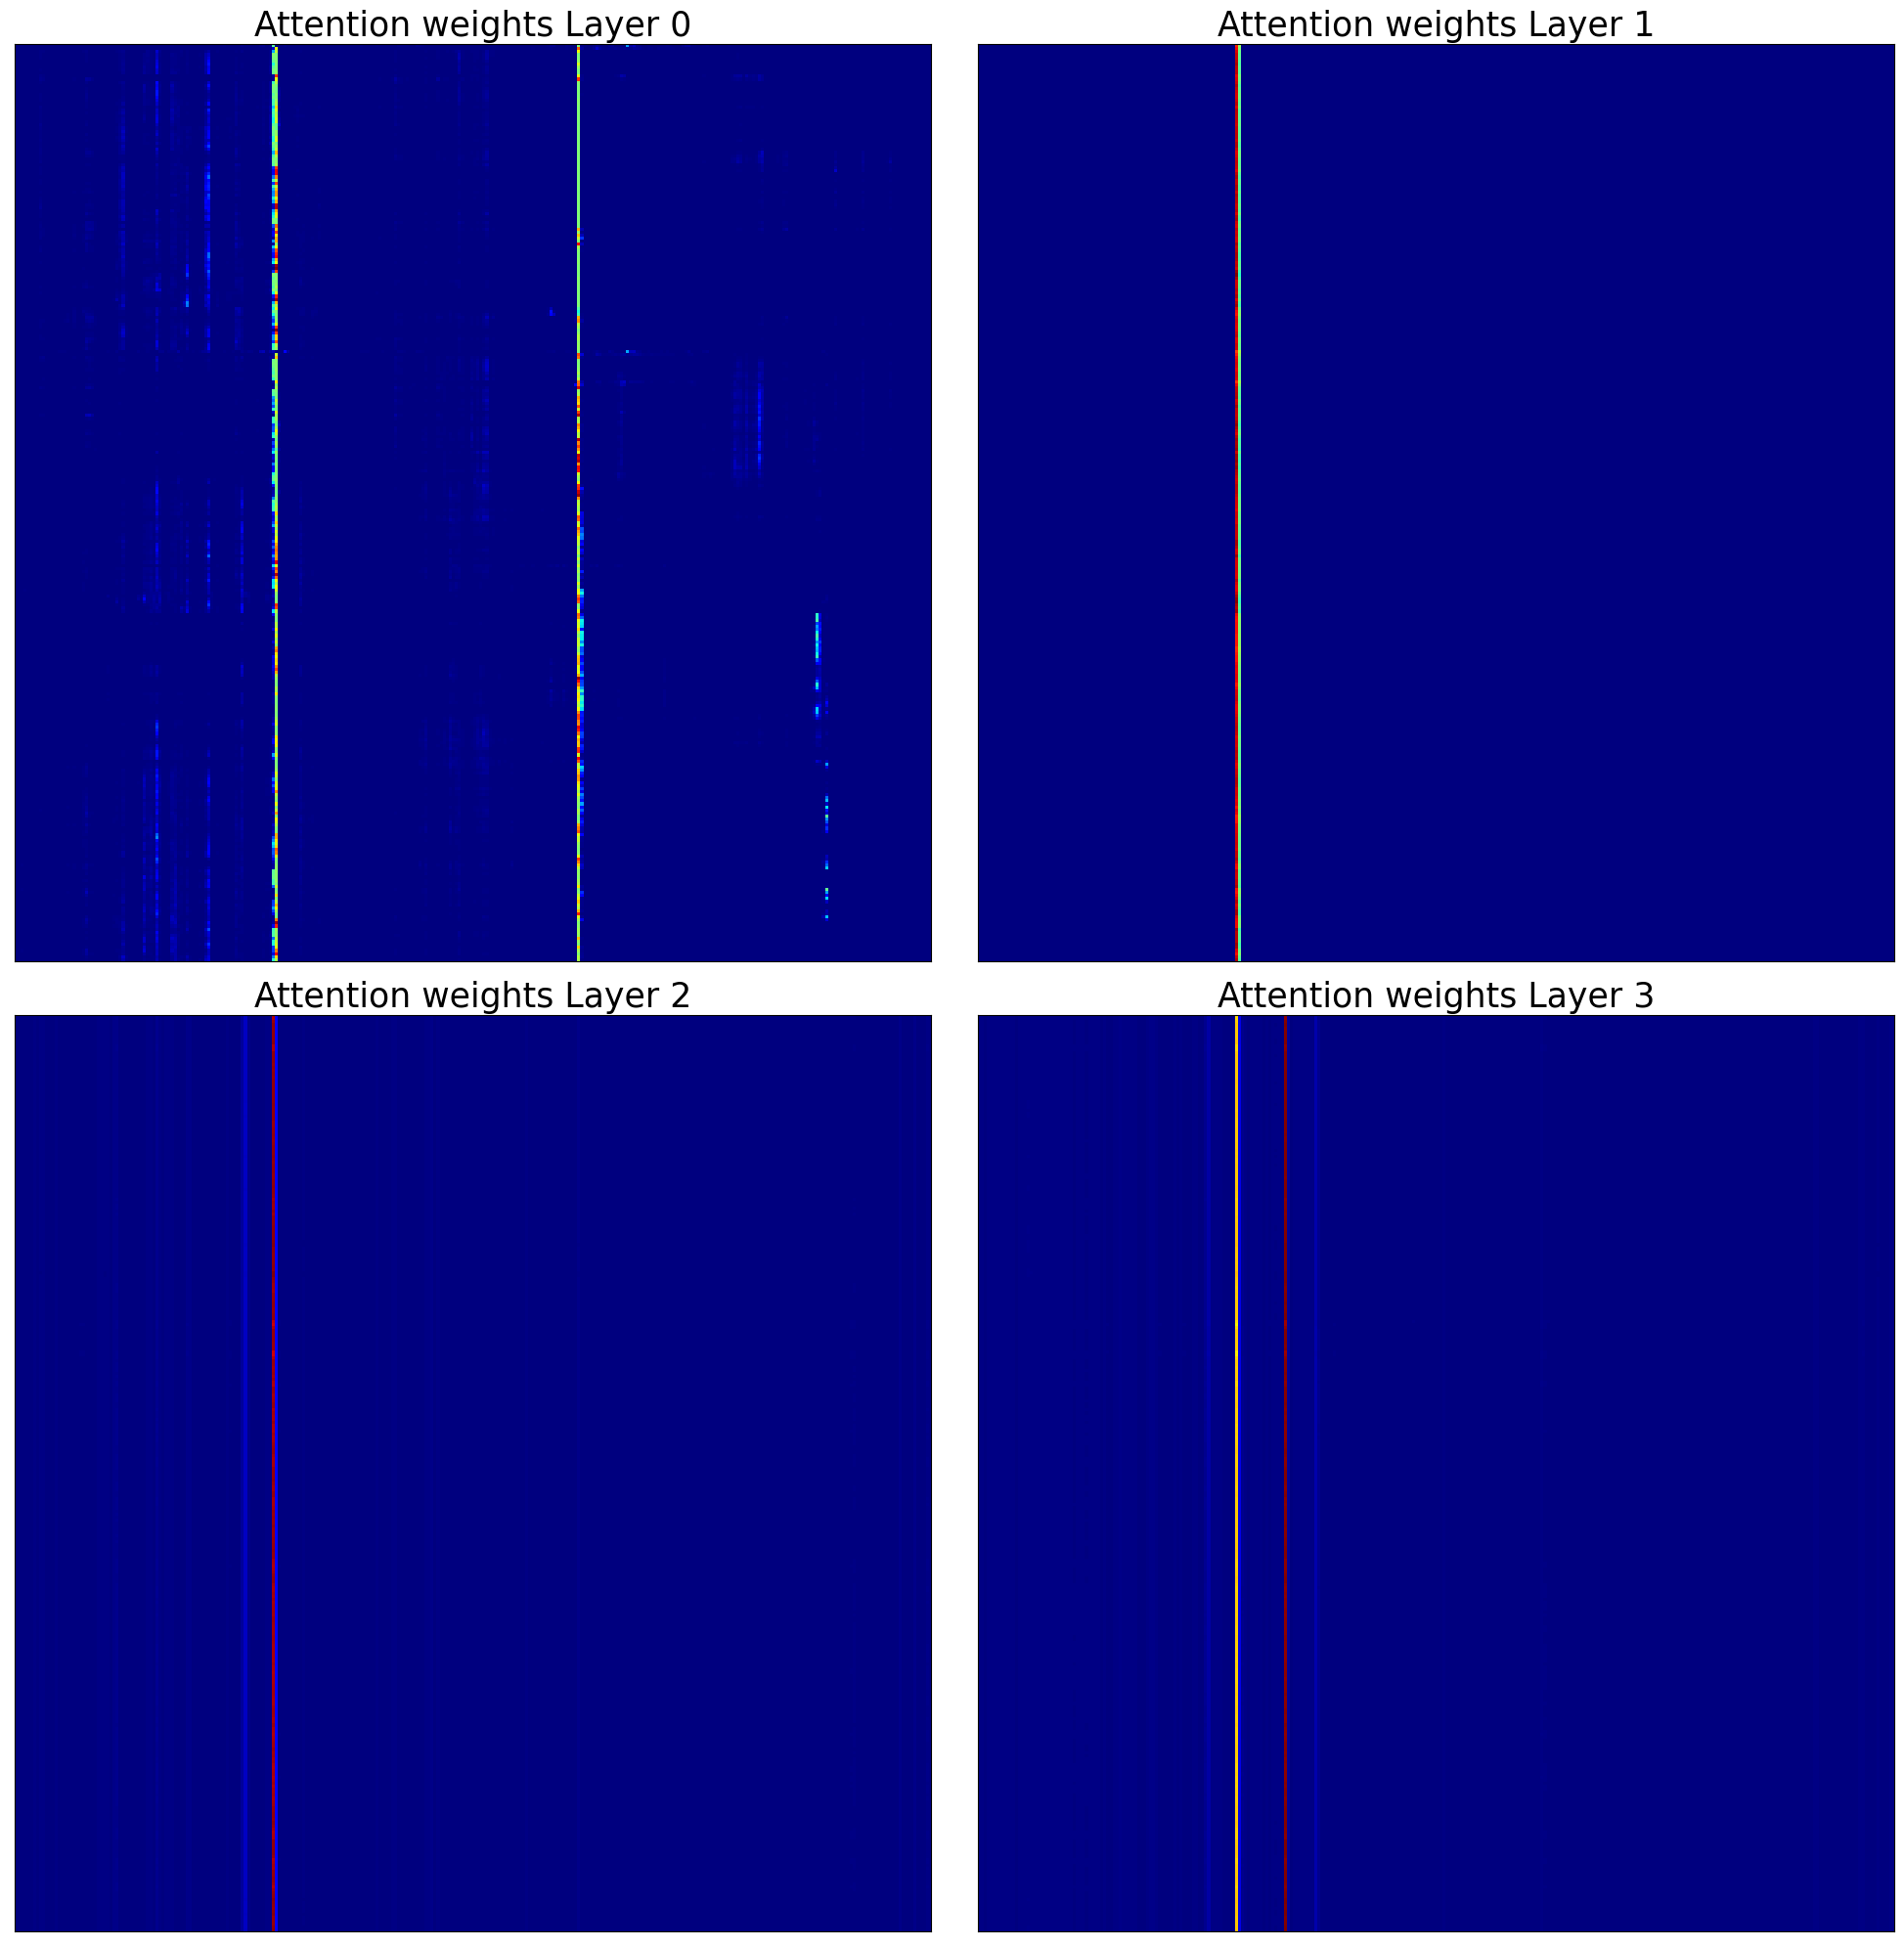

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(20, 20))
for idx, attn in enumerate(attn_weights):
    # Set title
    ax[idx // 2, idx % 2].set_title(f'Attention weights Layer {idx}', fontsize=25)
    ax[idx // 2, idx % 2].imshow(attn.squeeze().detach().numpy(), cmap='jet')
    ax[idx // 2, idx % 2].set_xticks([])
    ax[idx // 2, idx % 2].set_yticks([])

    fig.tight_layout()
    # fig.subplots_adjust(top=0.94)
plt.show()

In [18]:
attn_weights[0].shape

torch.Size([1, 300, 300])

In [19]:
attn_weights[0].mean(dim=2).max()

tensor(0.0033, grad_fn=<MaxBackward1>)

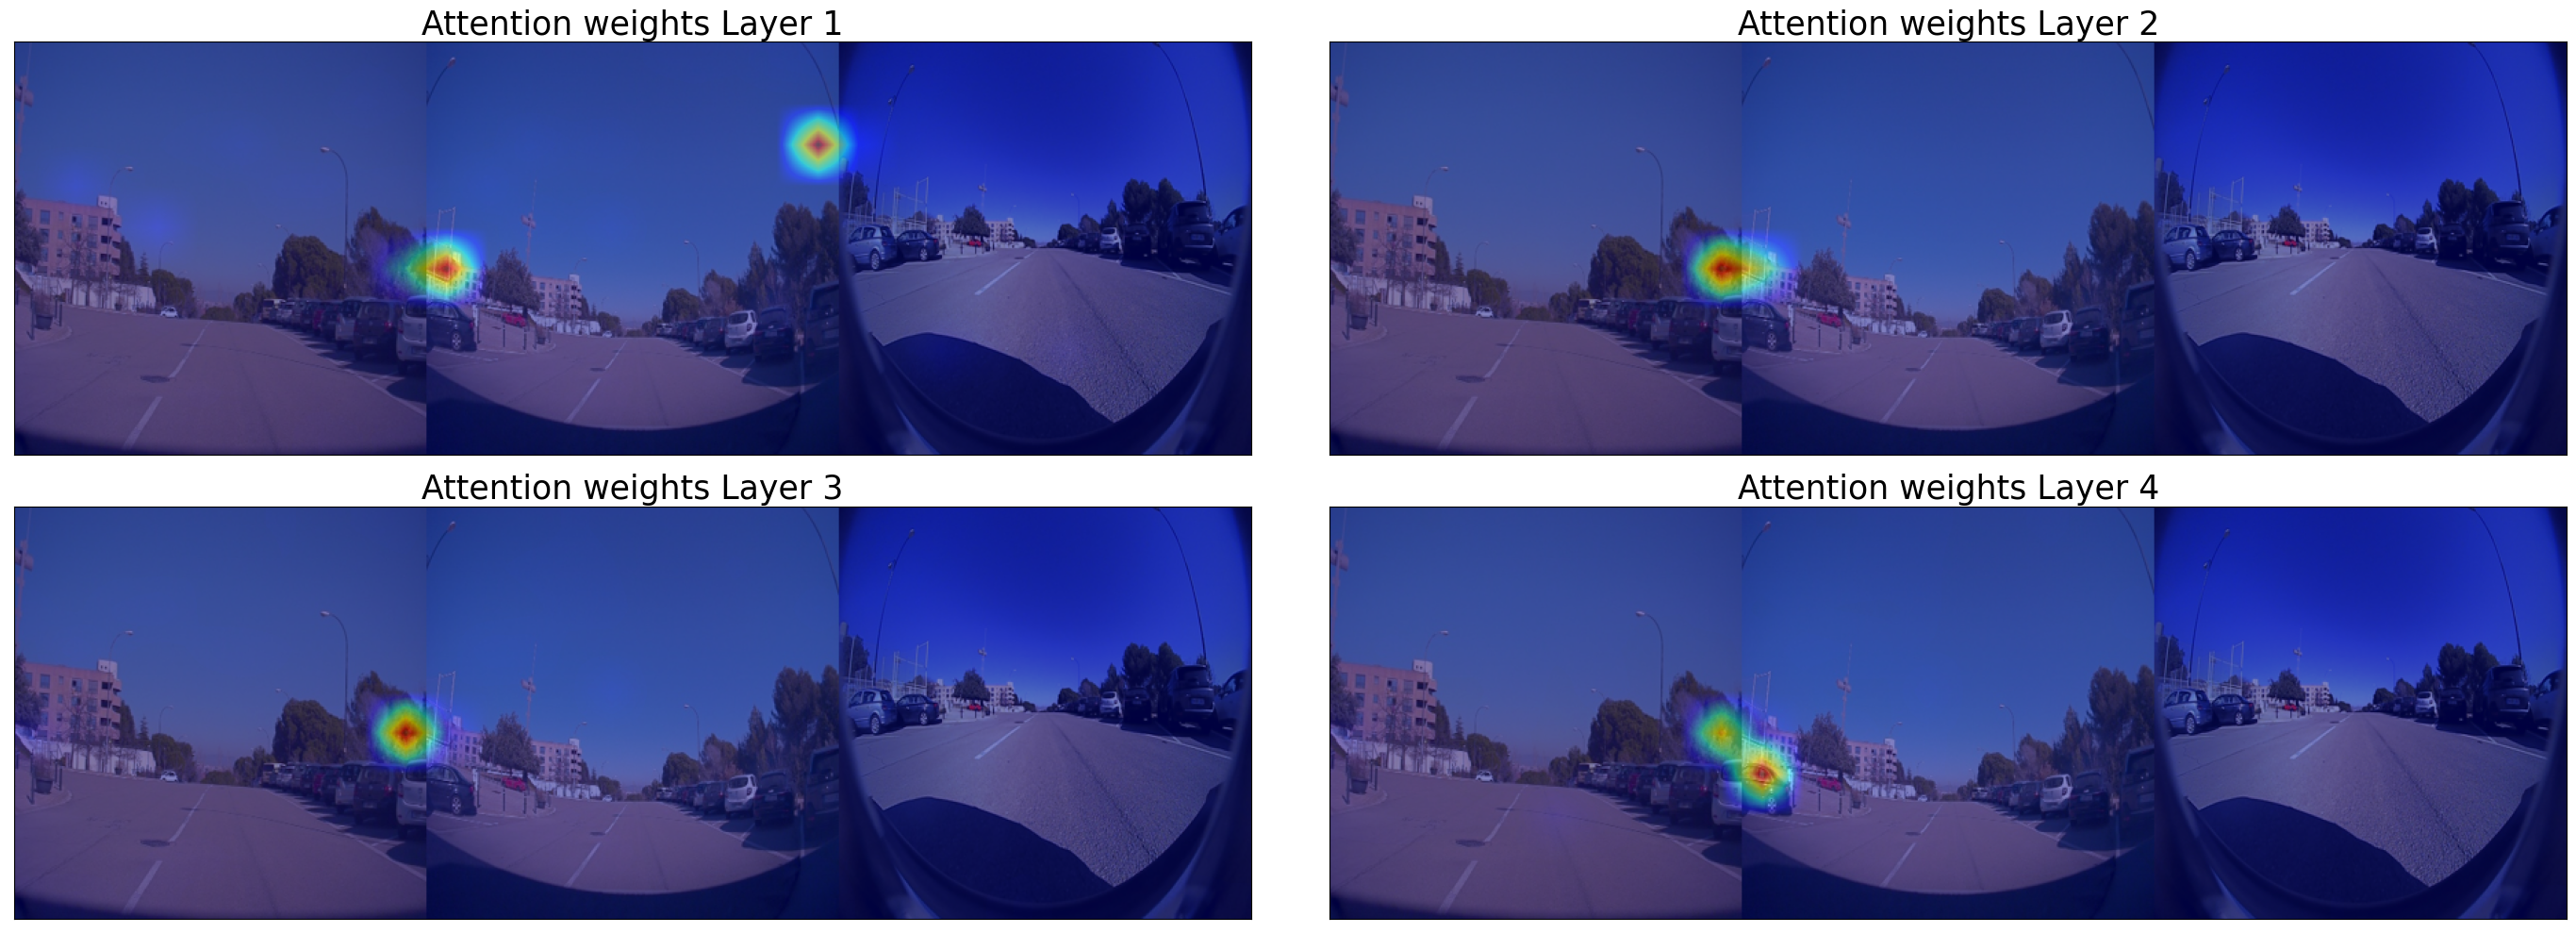

In [20]:
# Let's show them on top of the images
# First, concatenate horizontally the left, central, and right camera images
img_cat = torch.cat(src_images, dim=2)
img_cat = TF.normalize(img_cat, [-0.485/0.229, -0.456/0.224, -0.406/0.255], [1/0.229, 1/0.224, 1/0.255])
img_cat = torch.clamp(img_cat, 0, 1)
img_cat = img_cat.cpu().numpy().transpose(1, 2, 0)

fig, ax = plt.subplots(2, 2, figsize=(30, 10))
for idx, attn in enumerate(attn_weights):
    # Set title
    ax[idx // 2, idx % 2].set_title(f'Attention weights Layer {idx+1}', fontsize=25)
    ax[idx // 2, idx % 2].imshow(img_cat)
    # Plot attention weights
    attn = attn.squeeze().mean(dim=0)
    attn = rearrange(attn, '(h w cam) -> 1 h (w cam)' if (g_conf.ATTENTION_LOSS or g_conf.MHA_ATTENTION_COSSIM_LOSS or g_conf.MHA_ATTENTION_LOSS)
                        else '(cam h w) -> 1 h (cam w)', cam=cam, h=model.res_out_h)  # [B, 1, H//P, S*cam*W//P]
    attn = attn.detach().numpy().transpose(1, 2, 0)
    attn = cv2.resize(attn, (img_cat.shape[1], img_cat.shape[0]), interpolation=cv2.INTER_LINEAR)
    ax[idx // 2, idx % 2].imshow(attn, cmap='jet', alpha=0.5)
    ax[idx // 2, idx % 2].set_xticks([])
    ax[idx // 2, idx % 2].set_yticks([])

    fig.tight_layout()
    # fig.subplots_adjust(top=0.94)
plt.show()

## PCA of the Transformer Encoder Output?

In [27]:
in_memory.shape

torch.Size([1, 300, 512])

In [28]:
in_memory.min(), in_memory.max()

(tensor(-2.1097, grad_fn=<MinBackward1>),
 tensor(4.2298, grad_fn=<MaxBackward1>))

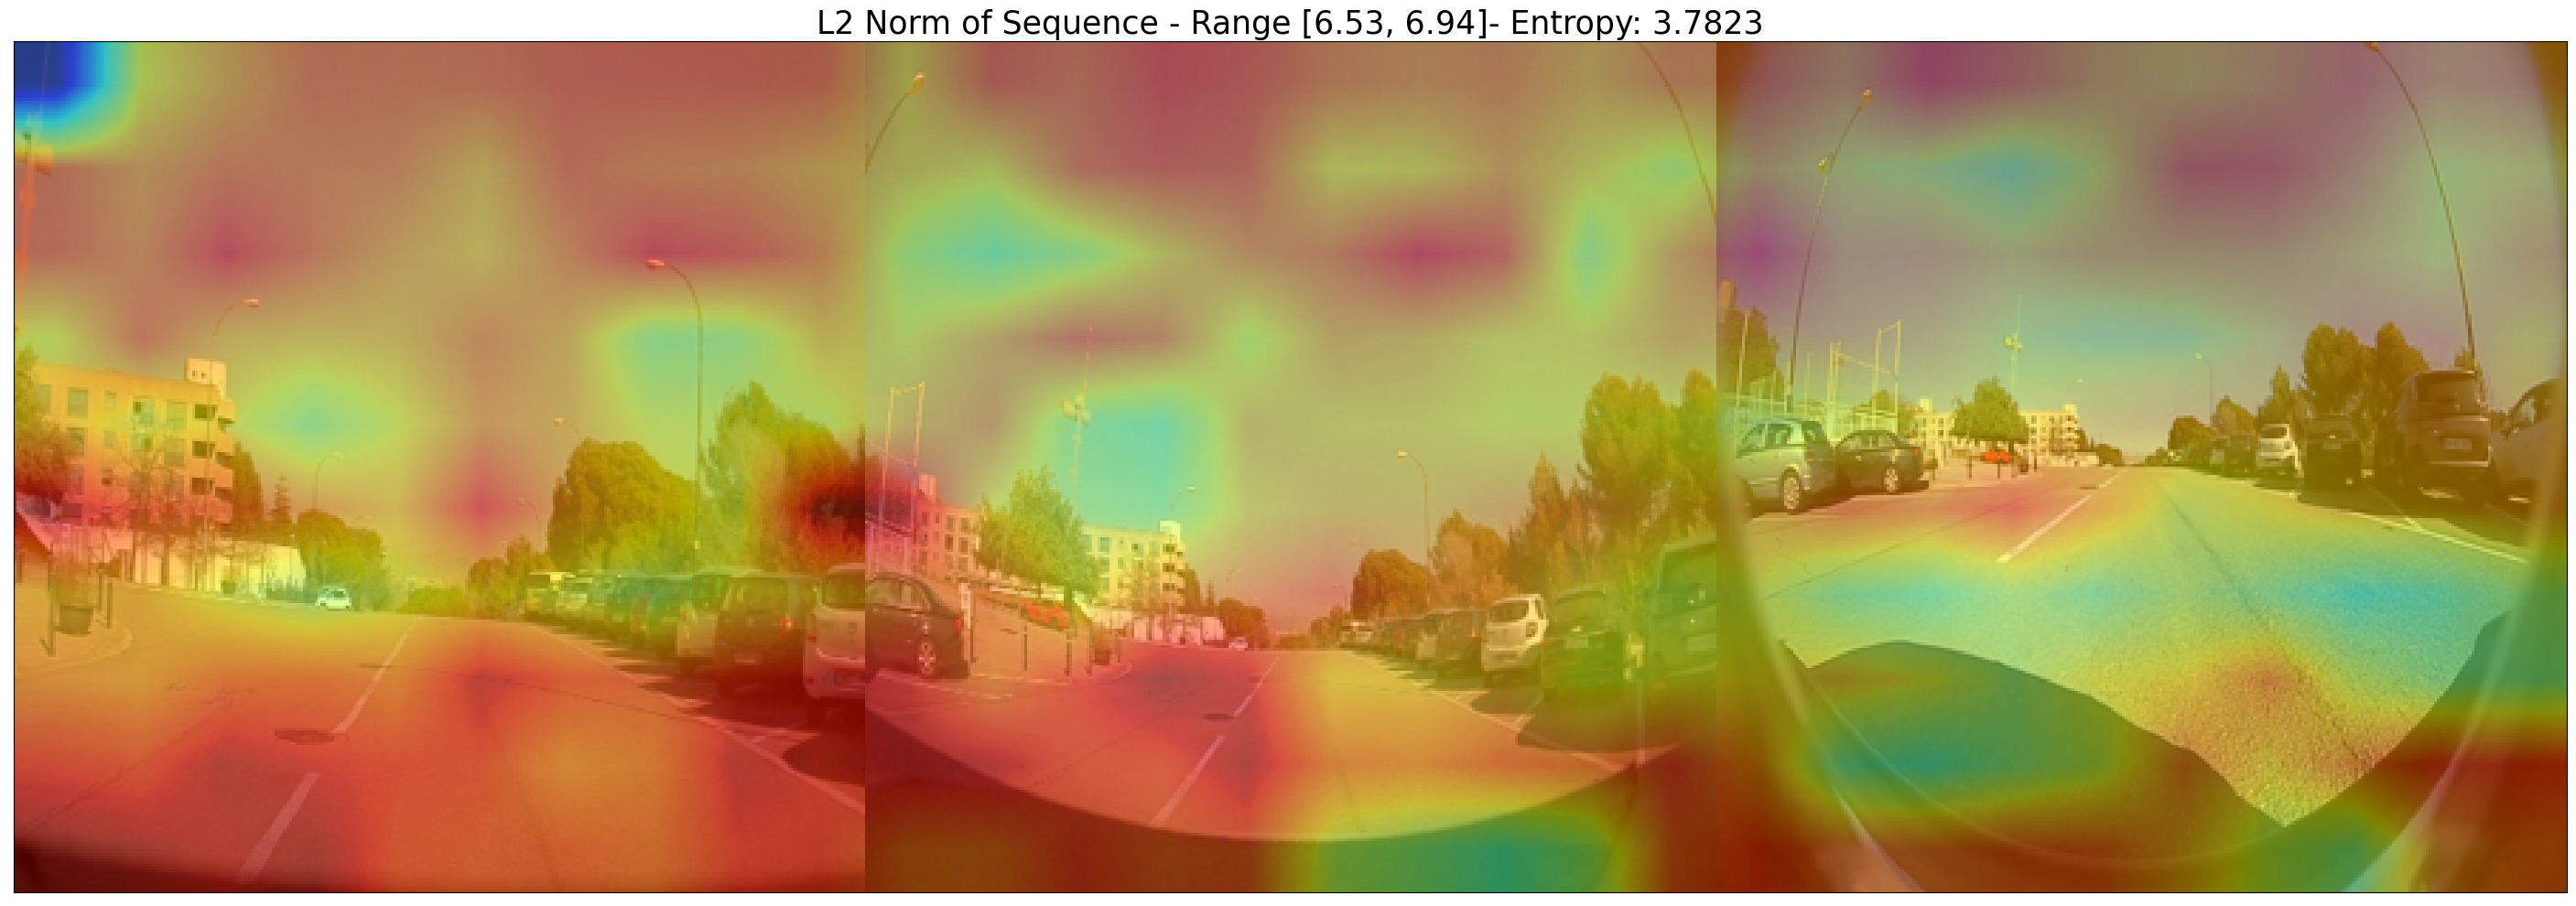

In [66]:
# Let's view the L2 norm of each patch

img_cat = torch.cat(src_images, dim=2)
img_cat = TF.normalize(img_cat, [-0.485/0.229, -0.456/0.224, -0.406/0.255], [1/0.229, 1/0.224, 1/0.255])
img_cat = torch.clamp(img_cat, 0, 1)
img_cat = img_cat.cpu().numpy().transpose(1, 2, 0)

# Get entropy
z = torch.norm(in_memory.squeeze(), p=2, dim=1)
counts, bins = np.histogram(z.detach().numpy(), bins=100)
entropy = - np.sum((counts / np.sum(counts)) * np.log((counts + 1e-8)/np.sum(counts)))

# Plot
fig, ax = plt.subplots(1, 1, figsize=(30, 10))

ax.set_title(f'L2 Norm of Sequence - Range [{z.min():.2f}, {z.max():.2f}]- Entropy: {entropy:.4f}', fontsize=25)
ax.imshow(img_cat)

# Plot attention weights
viz_z = rearrange(z, '(h w cam) -> 1 h (w cam)' if (g_conf.ATTENTION_LOSS or g_conf.MHA_ATTENTION_COSSIM_LOSS or g_conf.MHA_ATTENTION_LOSS)
                    else '(cam h w) -> 1 h (cam w)', cam=cam, h=model.res_out_h)  # [B, 1, H//P, S*cam*W//P]
viz_z = viz_z.detach().numpy().transpose(1, 2, 0)
viz_z = cv2.resize(viz_z, (img_cat.shape[1], img_cat.shape[0]), interpolation=cv2.INTER_LINEAR)
ax.imshow(viz_z, cmap='jet', alpha=0.5)
ax.set_xticks([])
ax.set_yticks([])

fig.tight_layout()
    # fig.subplots_adjust(top=0.94)
plt.show()

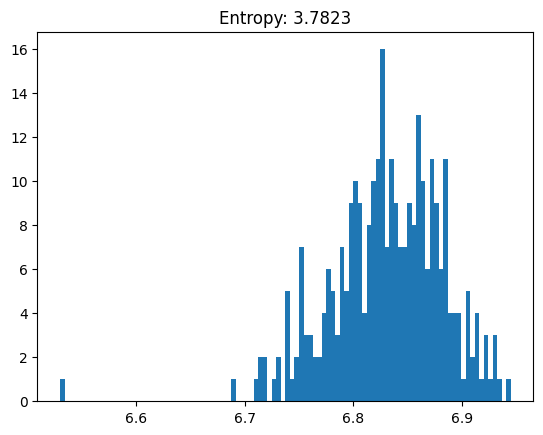

In [31]:
# Histogram plot of the norm of the sequence
counts, bins = np.histogram(z.detach().numpy(), bins=100)
plt.hist(bins[:-1], bins, weights=counts)

entropy = - np.sum((counts / np.sum(counts)) * np.log((counts + 1e-8)/np.sum(counts)))
plt.title(f'Entropy: {entropy:.4f}')

plt.show()

In [59]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale

pca = PCA(n_components=3)

# Set threshold; -100 for viewing all
threshold = 0

features = in_memory.detach().numpy()
batch_size, spatial_size, latent_dim = features.shape

features = features.reshape(-1, latent_dim)
pca.fit(features)

pca_features = pca.transform(features)

# segment using the first component
bg_mask = pca_features[:, 0] < threshold
fg_mask = ~bg_mask

# PCA for only foreground patches
# pca.fit(features[fg_mask])
pca_features_fg = pca.transform(features[fg_mask])
for i in range(3):
    pca_features_fg[:, i] = minmax_scale(pca_features_fg[:, i])

pca_features_rgb = pca_features.copy()
pca_features_rgb[bg_mask] = 0
pca_features_rgb[fg_mask] = pca_features_fg


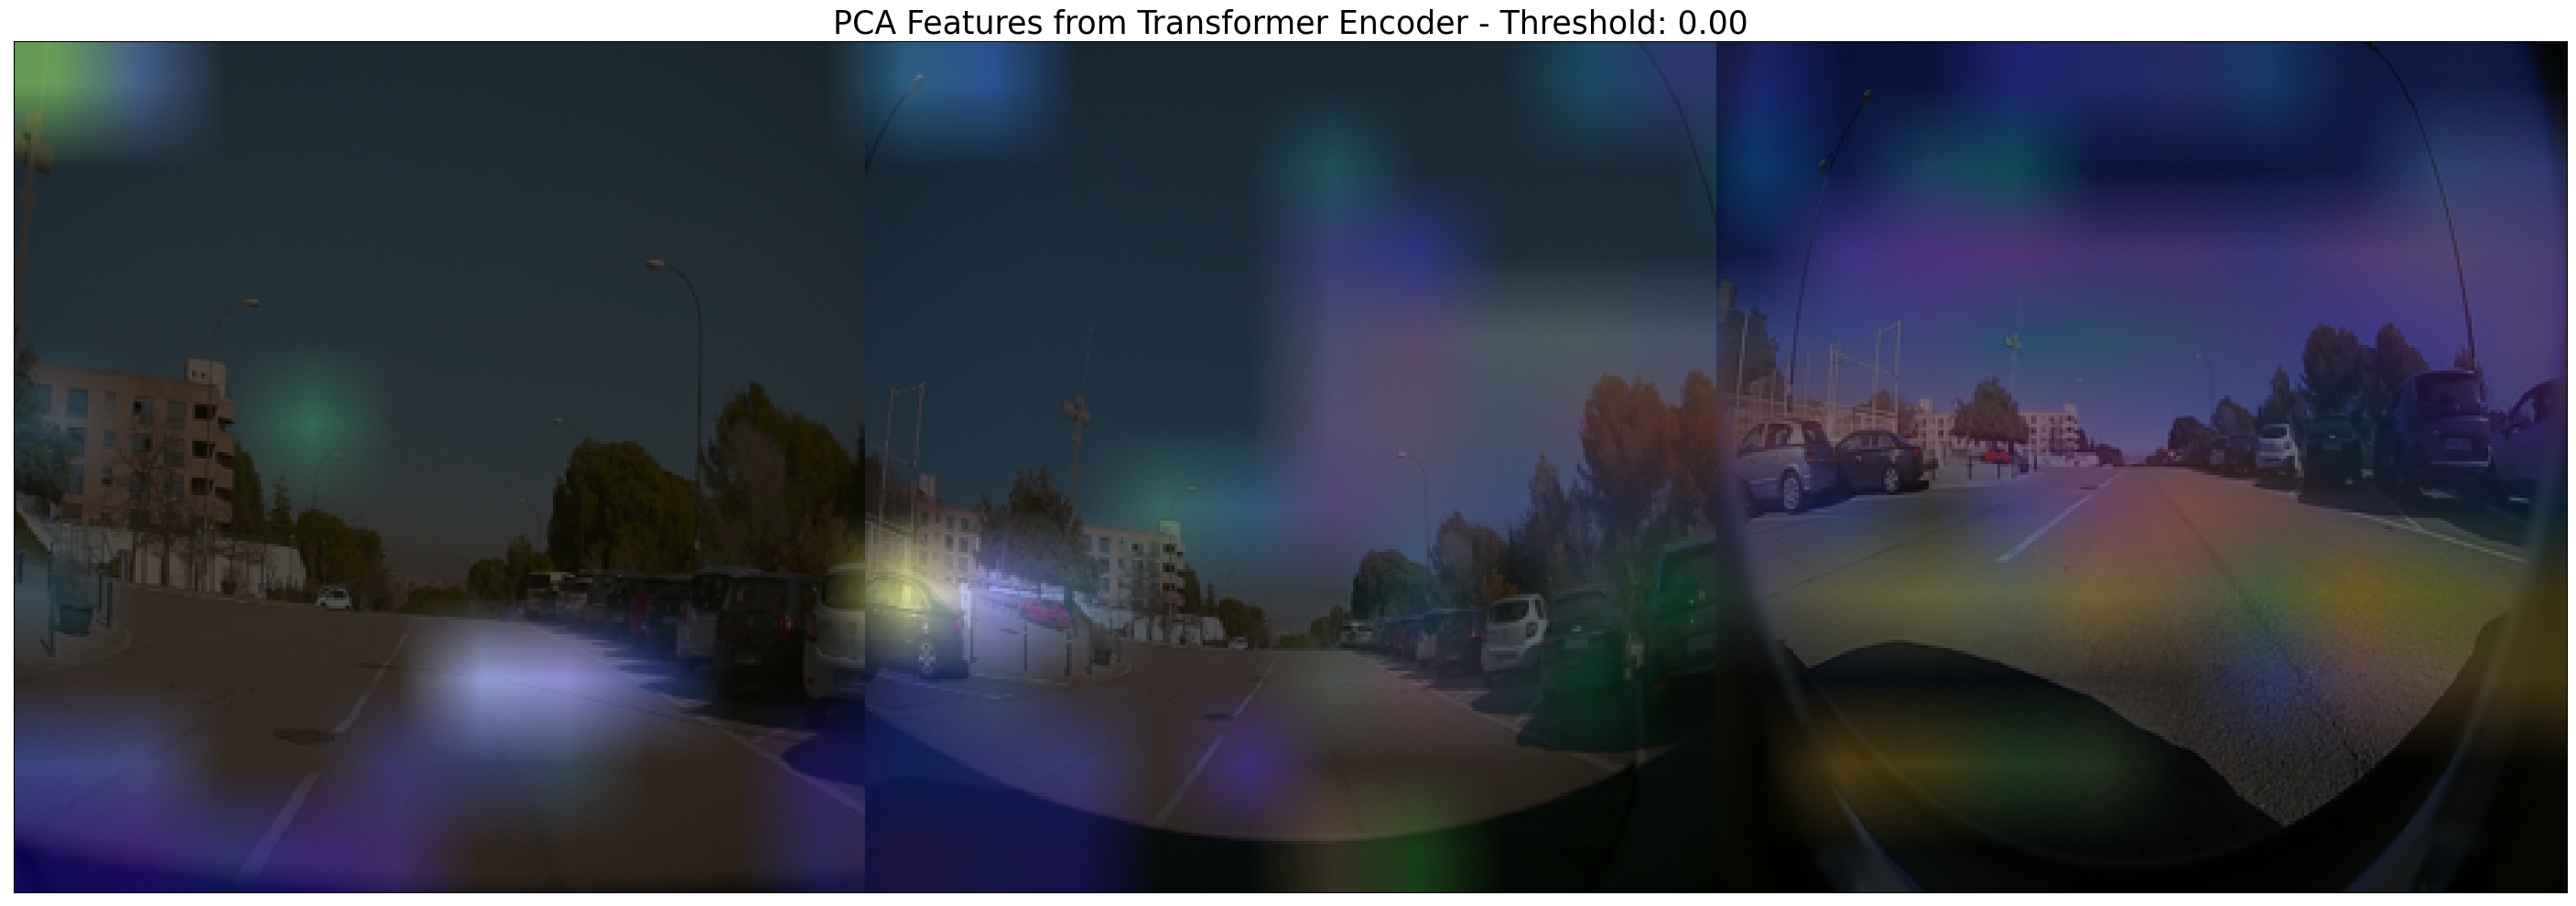

In [64]:
img_cat = torch.cat(src_images, dim=2)
img_cat = TF.normalize(img_cat, [-0.485/0.229, -0.456/0.224, -0.406/0.255], [1/0.229, 1/0.224, 1/0.255])
img_cat = torch.clamp(img_cat, 0, 1)
img_cat = img_cat.cpu().numpy().transpose(1, 2, 0)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(30, 10))

ax.set_title(f'PCA Features from Transformer Encoder - Threshold: {threshold:.2f}', fontsize=25)
ax.imshow(img_cat)

viz_pca_features_rgb = rearrange(pca_features_rgb, '(h w cam) c -> c h (w cam) ' if (g_conf.ATTENTION_LOSS or g_conf.MHA_ATTENTION_COSSIM_LOSS or g_conf.MHA_ATTENTION_LOSS)
                    else '(cam h w) c -> c h (cam w)', cam=cam, h=model.res_out_h, c=3)  # [B, C, H//P, S*cam*W//P]
viz_pca_features_rgb = viz_pca_features_rgb.transpose(1, 2, 0)
viz_pca_features_rgb = cv2.resize(viz_pca_features_rgb, (img_cat.shape[1], img_cat.shape[0]), interpolation=cv2.INTER_LINEAR)
ax.imshow(viz_pca_features_rgb, alpha=0.7)
ax.set_xticks([])
ax.set_yticks([])

fig.tight_layout()
    # fig.subplots_adjust(top=0.94)
plt.show()